In [13]:
# import packages
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)   # silence per-trial noise
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import xarray as xr
import cfgrib

In [14]:
MODEL_PATH   = 'test_best_temp_model_grid.pt'

In [15]:
# ── Load ALL variables ────────────────────────────────────────────────────────
# Read all unique shortNames in the file first
datasets = cfgrib.open_datasets("data/grid-timeseries_sel_vars_1940.grib")
print(f"Found {len(datasets)} variable groups:")
for i, d in enumerate(datasets):
    print(f"  [{i}] variables: {list(d.data_vars)}, dims: {dict(d.dims)}")

Found 2 variable groups:
  [0] variables: ['sp', 'tcc', 'u10', 'v10', 't2m'], dims: {'time': 8784, 'latitude': 5, 'longitude': 5}
  [1] variables: ['ssrd', 'tp'], dims: {'time': 732, 'step': 12, 'latitude': 5, 'longitude': 5}


c:\Users\maili\anaconda3\envs\weather\Lib\site-packages\cfgrib\xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
c:\Users\maili\anaconda3\envs\weather\Lib\site-packages\cfgrib\xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
c:\Users\maili

In [18]:
LAG     = 72  # 72 hours of history (was 20)
HORIZON = 24   # predict 24h ahead (was -1)
N_TRIALS     = 3    # Optuna trials (was 20)
OPTUNA_EPOCHS = 5   # max epochs per trial (was 80)
FINAL_EPOCHS  = 15   # final training budget
BATCH         =  512  # larger batch = faster GPU/CPU steps
SEED          = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

In [19]:
# ── Load ALL variables ────────────────────────────────────────────────────────
datasets = cfgrib.open_datasets("data/grid-timeseries_sel_vars_1940.grib")
ds0      = datasets[0]
ref_lat  = ds0.latitude
ref_lon  = ds0.longitude
ref_time = ds0.time
channels   = []
chan_names = []
for var in ['sp', 'tcc', 'u10', 'v10', 't2m']:
    channels.append(ds0[var].values.astype(np.float32))
    chan_names.append(var)
ds1 = datasets[1]
for var in ['ssrd', 'tp']:
    arr = ds1[var]
    arr_summed = arr.sum(dim='step')
    daily_time = arr.time.values
    arr_daily  = xr.DataArray(
        arr_summed.values / 24,
        coords={'time': daily_time, 'latitude': ref_lat, 'longitude': ref_lon},
        dims=['time', 'latitude', 'longitude']
    )
    arr_hourly = arr_daily.reindex(time=ref_time, method='ffill').ffill(dim='time').bfill(dim='time')
    channels.append(arr_hourly.values.astype(np.float32))
    chan_names.append(var)

X_raw      = np.stack(channels, axis=1).astype(np.float32)
tp_idx     = chan_names.index('tp')
y_raw      = channels[tp_idx].copy()
N_FEATURES = len(chan_names)
N          = X_raw.shape[0]

# Fill NaNs
for i in range(X_raw.shape[1]):
    ch = X_raw[:, i]
    ch_mean = np.nanmean(ch)
    X_raw[:, i] = np.where(np.isnan(ch), ch_mean, ch)
    X_raw[:, i] = np.where(np.isinf(ch), ch_mean, X_raw[:, i])
y_mean_fill = np.nanmean(y_raw)
y_raw = np.where(np.isnan(y_raw), y_mean_fill, y_raw)
y_raw = np.where(np.isinf(y_raw), y_mean_fill, y_raw)

# Log transform
y_raw = y_raw * 1000
y_raw = np.log1p(y_raw)
X_raw[:, tp_idx] = np.log1p(X_raw[:, tp_idx] * 1000)


# Fill NaNs introduced by lagging
for i in range(X_raw.shape[1]):
    ch = X_raw[:, i]
    ch_mean = np.nanmean(ch)
    X_raw[:, i] = np.where(np.isnan(ch), ch_mean, ch)

N_FEATURES = len(chan_names)   # updates to 63
N          = X_raw.shape[0]
print(f"New channel count: {N_FEATURES}")
# ─────────────────────────────────────────────────────────────────────────────

train_end = int(0.70 * N)
test_end  = int(0.90 * N)
print(f"N={N}, train={train_end}, test={test_end-train_end}, val={N-test_end}")
print(f"X_raw: {X_raw.shape}  →  (T, {N_FEATURES} channels, H, W)")
print(f"y_raw: {y_raw.shape}  ← precipitation (tp) target")

c:\Users\maili\anaconda3\envs\weather\Lib\site-packages\cfgrib\xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
c:\Users\maili\anaconda3\envs\weather\Lib\site-packages\cfgrib\xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)
c:\Users\maili

New channel count: 7
N=8784, train=6148, test=1757, val=879
X_raw: (8784, 7, 5, 5)  →  (T, 7 channels, H, W)
y_raw: (8784, 5, 5)  ← precipitation (tp) target


In [20]:
def make_windows(X, y, lag=LAG, horizon=HORIZON):
    Xw, yw = [], []
    for i in range(lag, len(X) - horizon):
        Xw.append(X[i - lag:i])       # (lag, C, H, W)
        yw.append(y[i + horizon])      # (H, W)
    return np.array(Xw, dtype=np.float32), np.array(yw, dtype=np.float32)
# Output shapes:
# X_train_w: (samples, lag, channels, H, W)
# y_train:   (samples, H, W)

def make_windows_X(X, lag=LAG):
    return np.array([X[i - lag:i] for i in range(lag, len(X))], dtype=np.float32)

X_train_w, y_train = make_windows(X_raw[:train_end],         y_raw[:train_end])
X_test_w,  y_test  = make_windows(X_raw[train_end:test_end], y_raw[train_end:test_end])
X_val_w,   y_val   = make_windows(X_raw[test_end:],          y_raw[test_end:])
print(f"train {X_train_w.shape} | test {X_test_w.shape} | val {X_val_w.shape}")

# Replace fit_scale and transform with this:
def fit_scale(Xw):
    N, T, C, H, W = Xw.shape
    flat = Xw.reshape(-1, C)
    mean = flat.mean(axis=0)
    std  = flat.std(axis=0) + 1e-8
    return mean, std

def transform(Xw, sc):
    mean, std = sc
    N, T, C, H, W = Xw.shape
    return ((Xw.reshape(-1, C) - mean) / std).reshape(N, T, C, H, W).astype(np.float32)

scaler  = fit_scale(X_train_w)
X_tr_sc = transform(X_train_w, scaler)
X_te_sc = transform(X_test_w,  scaler)
X_va_sc = transform(X_val_w,   scaler)
y_mean, y_std  = y_train.mean(), y_train.std()
y_tr_n = y_train
y_te_n = y_test  
y_va_n = y_val

y_mean = 0.0
y_std  = 1.0

# ── 4. DATASET ────────────────────────────────────────────────────────────────
class SeqDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
    def __len__(self):        return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

def loader(X, y, shuffle): return DataLoader(SeqDS(X, y), batch_size=BATCH, shuffle=shuffle)

# ── 5. MODELS ─────────────────────────────────────────────────────────────────
class ConvLSTMCell(nn.Module):
    def __init__(self, in_channels, hidden_channels, kernel_size=3):
        super().__init__()
        pad = kernel_size // 2
        self.hidden_channels = hidden_channels
        self.conv = nn.Conv2d(
            in_channels + hidden_channels,
            4 * hidden_channels,
            kernel_size, padding=pad
        )

    def forward(self, x, h, c):
        combined = torch.cat([x, h], dim=1)
        gates = self.conv(combined)
        i, f, o, g = gates.chunk(4, dim=1)
        c = torch.sigmoid(f) * c + torch.sigmoid(i) * torch.tanh(g)
        h = torch.sigmoid(o) * torch.tanh(c)
        return h, c

class ConvLSTMModel(nn.Module):
    def __init__(self, in_channels, hidden_channels=32, kernel_size=3):
        super().__init__()
        self.cell = ConvLSTMCell(in_channels, hidden_channels, kernel_size)
        self.fc   = nn.Conv2d(hidden_channels, 1, kernel_size=1)

    def forward(self, x):
        B, T, C, H, W = x.shape
        h = torch.zeros(B, self.cell.hidden_channels, H, W).to(x.device)  # follows input
        c = torch.zeros(B, self.cell.hidden_channels, H, W).to(x.device)
        for t in range(T):
            h, c = self.cell(x[:, t], h, c)
        return self.fc(h).squeeze(1)

# ── 6. TRAIN HELPER ───────────────────────────────────────────────────────────
def run_training(model, X_tr, y_tr, X_v, y_v, lr, max_epochs, patience, trial=None):
    tr_loader = loader(X_tr, y_tr, shuffle=True)
    va_loader = loader(X_v,  y_v,  shuffle=False)
    opt  = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)

    best_val, no_improve = float('inf'), 0
    for epoch in range(max_epochs):
        model.train()
        for xb, yb in tr_loader:
            opt.zero_grad()
            F.mse_loss(model(xb), yb).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        model.eval()
        with torch.no_grad():
            vals = [F.mse_loss(model(xb), yb).item() for xb, yb in va_loader]
        avg = float(np.mean(vals))
        sched.step(avg)

        if avg < best_val:
            best_val, no_improve = avg, 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

        if trial:
            trial.report(avg, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

    return best_val

# ── 7. OPTUNA ────────────────────────────────────────────────────────────────
def objective(trial):
    hidden = trial.suggest_categorical('hidden', [32, 64, 128])  # was [16, 32, 64]
    lr     = trial.suggest_float('lr', 1e-5, 5e-4, log=True)     # was 1e-4 to 5e-3
    kernel = trial.suggest_categorical('kernel', [3, 5])
    model  = ConvLSTMModel(N_FEATURES, hidden_channels=hidden, kernel_size=kernel)
    return run_training(model, X_tr_sc, y_tr_n, X_va_sc, y_va_n,
                        lr=lr, max_epochs=OPTUNA_EPOCHS, patience=3, trial=trial)  # patience 5→3

study = optuna.create_study(
    direction='minimize',
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=2,   # was 3
        n_warmup_steps=3      # was 5
    )
)
study.optimize(objective, n_trials=N_TRIALS)
bp = study.best_params
print("Best params:", bp)
print("Best val MSE:", f"{study.best_value:.6f}")

# ── 8. FINAL MODEL ────────────────────────────────────────────────────────────
model = ConvLSTMModel(N_FEATURES,
                      hidden_channels=bp['hidden'],
                      kernel_size=bp['kernel'])

tr_loader = loader(X_tr_sc, y_tr_n, shuffle=True)
va_loader = loader(X_va_sc, y_va_n, shuffle=False)
opt   = torch.optim.Adam(model.parameters(), lr=bp['lr'])
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=6, factor=0.5)

train_losses, val_losses = [], []
best_val, no_improve     = float('inf'), 0
best_state               = copy.deepcopy(model.state_dict())

print(f"\nFinal training — up to {FINAL_EPOCHS} epochs …")
for epoch in range(FINAL_EPOCHS):
    model.train()
    tl = []
    for xb, yb in tr_loader:
        opt.zero_grad()
        loss = F.mse_loss(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        tl.append(loss.item())
    train_losses.append(np.mean(tl))

    model.eval()
    with torch.no_grad():
        vl = []
        for xb, yb in va_loader:
            vl.append(F.mse_loss(model(xb), yb).item())
    avg_val = float(np.mean(vl))
    val_losses.append(avg_val)

    print(f"  Epoch {epoch+1:03d} | train {train_losses[-1]:.5f} | val {avg_val:.5f}")

    if avg_val < best_val:
        best_val, no_improve = avg_val, 0
        best_state = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), MODEL_PATH)
    else:
        no_improve += 1
        if no_improve >= 12:
            print(f"  Early stop at epoch {epoch+1}")
            break
model.load_state_dict(best_state)


train (6052, 72, 7, 5, 5) | test (1661, 72, 7, 5, 5) | val (783, 72, 7, 5, 5)


[W 2026-05-31 10:57:30,432] Trial 2 failed with parameters: {'hidden': 128, 'lr': 0.00010385084680471049, 'kernel': 5} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\maili\anaconda3\envs\weather\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\maili\AppData\Local\Temp\ipykernel_29292\3380037623.py", line 130, in objective
    return run_training(model, X_tr_sc, y_tr_n, X_va_sc, y_va_n,
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\maili\AppData\Local\Temp\ipykernel_29292\3380037623.py", line 100, in run_training
    F.mse_loss(model(xb), yb).backward()
  File "c:\Users\maili\anaconda3\envs\weather\Lib\site-packages\torch\_tensor.py", line 631, in backward
    torch.autograd.backward(
  File "c:\Users\maili\anaconda3\envs\weather\Lib\site-packages\torch\autograd\__init__.py", line 379, in b

KeyboardInterrupt: 

In [ ]:
# ── 9. EVALUATE ───────────────────────────────────────────────────────────────

def predict(X_sc):
    model.eval()
    with torch.no_grad():
        preds = []
        loader_pred = DataLoader(torch.from_numpy(X_sc), batch_size=BATCH)
        for xb in loader_pred:
            preds.append(model(xb.to(device)).cpu().numpy())
    pred = np.concatenate(preds, axis=0)     # (N, H, W) — still in log-mm normalized space
    pred = pred * y_std + y_mean             # denormalize → log-mm
    return np.clip(np.expm1(pred), 0, None)  # undo log1p → mm, clip negatives

y_test_pred = predict(X_te_sc)
y_val_pred  = predict(X_va_sc)
y_test_mm   = np.expm1(y_test * y_std + y_mean)   # ground truth back to mm
y_val_mm    = np.expm1(y_val  * y_std + y_mean)

# ── Overall metrics ───────────────────────────────────────────────────────────
test_rmse = np.sqrt(mean_squared_error(y_test_mm.flatten(), y_test_pred.flatten()))
test_r2   = r2_score(y_test_mm.flatten(), y_test_pred.flatten())
print(f"=== Overall ===")
print(f"Test RMSE : {test_rmse:.4f} mm")
print(f"Test R²   : {test_r2:.4f}")

# ── 17:00 mask ────────────────────────────────────────────────────────────────
# Reconstruct timestamps for test set windows
test_times = pd.to_datetime(
    ds0.time.values[train_end + LAG : train_end + LAG + len(y_test)]
)
mask_17 = test_times.hour == 17

y_test_17      = y_test_mm[mask_17]
y_test_pred_17 = y_test_pred[mask_17]

rmse_17 = np.sqrt(mean_squared_error(y_test_17.flatten(), y_test_pred_17.flatten()))
r2_17   = r2_score(y_test_17.flatten(), y_test_pred_17.flatten())
print(f"\n=== 17:00 only (afternoon convective) ===")
print(f"Test RMSE : {rmse_17:.4f} mm")
print(f"Test R²   : {r2_17:.4f}")
print(f"Samples   : {mask_17.sum()} windows")

# ── Loss curves (log scale) ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(train_losses, label='Train')
axes[0].plot(val_losses,   label='Val')
axes[0].set_title('Loss Curve (linear)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(train_losses, label='Train')
axes[1].plot(val_losses,   label='Val')
axes[1].set_yscale('log')
axes[1].set_title('Loss Curve (log scale)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE (log)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Spatial MAE map ───────────────────────────────────────────────────────────
mae_map    = np.abs(y_test_mm    - y_test_pred).mean(axis=0)   # (H, W)
mae_map_17 = np.abs(y_test_17    - y_test_pred_17).mean(axis=0)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for row, (obs, pred, mask_label) in enumerate([
    (y_test_mm, y_test_pred, 'All hours'),
    (y_test_17, y_test_pred_17, '17:00 only')
]):
    im0 = axes[row,0].imshow(obs.mean(axis=0),  cmap='Blues')
    axes[row,0].set_title(f'Observed mean ({mask_label})')
    plt.colorbar(im0, ax=axes[row,0], label='mm')

    im1 = axes[row,1].imshow(pred.mean(axis=0), cmap='Blues')
    axes[row,1].set_title(f'Predicted mean ({mask_label})')
    plt.colorbar(im1, ax=axes[row,1], label='mm')

    im2 = axes[row,2].imshow(np.abs(obs - pred).mean(axis=0), cmap='Reds')
    axes[row,2].set_title(f'MAE ({mask_label})')
    plt.colorbar(im2, ax=axes[row,2], label='mm')

plt.tight_layout()
plt.show()

NameError: name 'torch' is not defined

Test RMSE: 0.0681 °C


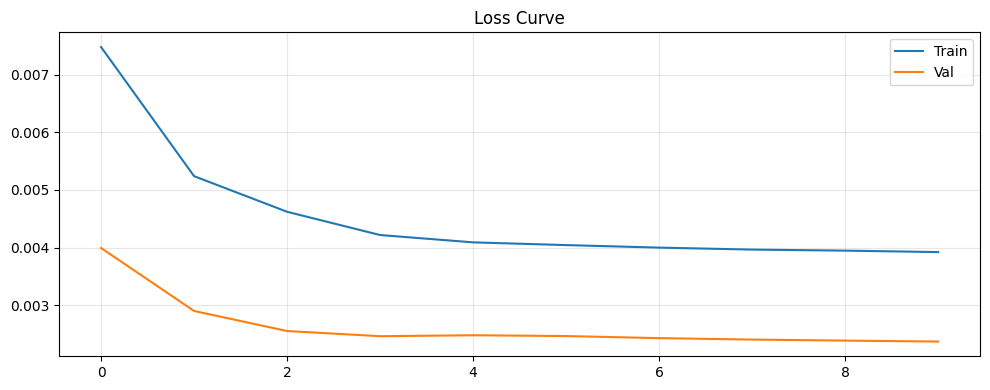

In [ ]:
# ── 9. EVALUATE ───────────────────────────────────────────────────────────────
def predict(X_sc):
    model.eval()
    with torch.no_grad():
        pred = model(torch.from_numpy(X_sc)).numpy()  # (N, H, W)
    return pred * y_std + y_mean

# RMSE averaged over all grid points

y_test_pred = predict(X_te_sc)
y_val_pred  = predict(X_va_sc)
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test.flatten(), y_test_pred.flatten())):.4f} °C")

# Loss curve
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Train')
ax.plot(val_losses, label='Val')
ax.set_title('Loss Curve'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

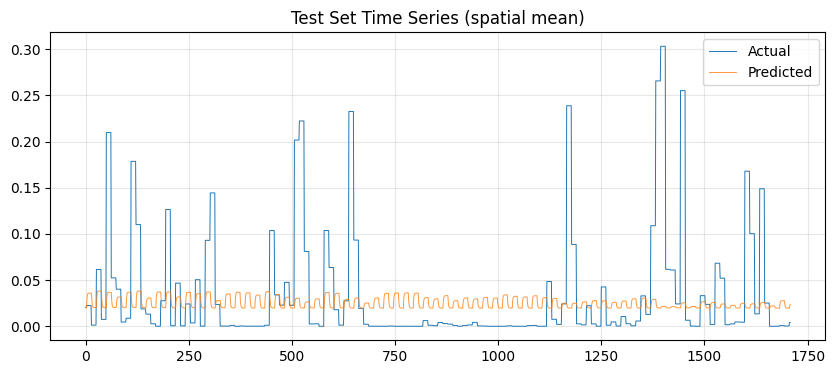

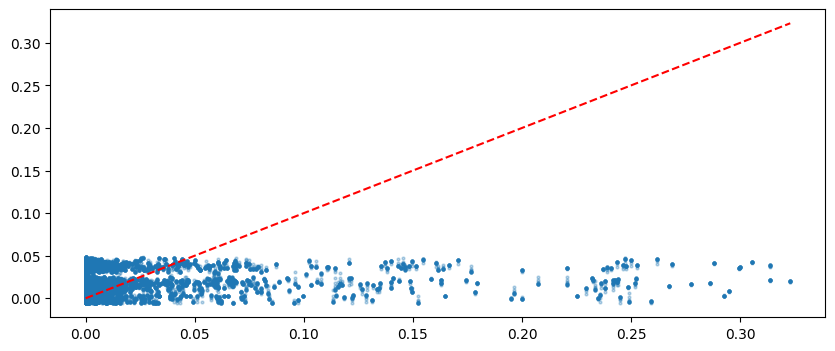

In [ ]:
# Collapse the H×W grid to a single number per timestep
y_test_ts      = y_test.mean(axis=(1, 2))       # (413,)
y_test_pred_ts = y_test_pred.mean(axis=(1, 2))  # (413,)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(y_test_ts,      linewidth=0.7, label='Actual')
ax.plot(y_test_pred_ts, linewidth=0.7, label='Predicted', alpha=0.8)
ax.set_title('Test Set Time Series (spatial mean)'); ax.legend(); ax.grid(True, alpha=0.3)
fig, ax = plt.subplots(figsize=(10, 4))
# flatten() already works but y_val is also 3D — it just happened to not crash yet
ax.scatter(y_val.flatten(), y_val_pred.flatten(), alpha=0.3, s=4)
ax.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')